<a href="https://colab.research.google.com/github/genaiconference/Agentic_KAG_Workshop_DHS_2026/blob/main/04_movie_intel_community_detection_summarization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Movie Community Detection and Summarization

## Objective
Build an end-to-end **community-based GraphRAG** pipeline for a Movie Knowledge Graph using Neo4j Graph Data Science (GDS) and an LLM — from detecting communities to answering questions with global & local search.



## 🎯 Learning Objectives

By the end of this workshop, you will be able to:

1. **Understand what a "community" is** in a knowledge graph — a densely connected cluster of nodes (e.g., a group of movies, actors, and genres that frequently appear together).
2. **Explain why community detection matters** for GraphRAG — summarizing clusters lets an LLM reason over *themes* instead of thousands of individual nodes.
3. **Project a Neo4j graph** into the Graph Data Science (GDS) in-memory catalog.
4. **Run the Leiden algorithm** to assign each node a `community` id.
5. **Retrieve and inspect** the nodes and relationships that make up each community.
6. **Summarize each community with an LLM** to produce human-readable, natural-language descriptions.
7. **Persist those summaries** back into Neo4j as `Community` nodes, linked to members via `:IN_COMMUNITY`.
8. **Visualize communities** on Neo4j.
9. **Embed community summaries** and build a Neo4j vector index for semantic search.
10. **Retrieve communities → movies** to answer questions with grounded GraphRAG.
11. **Wrap global & local search as LangChain tools** you can reuse in any application.

> 💡 **New to graphs?** Think of a community like a "friend group" on social media — people (nodes) who are tightly linked to each other, but less connected to those outside the group.


## 🏗️ Architecture

The pipeline flows from the raw graph all the way to grounded, question-answering tools:

```text
        ┌─────────────────────────┐
        │      Movie KG (Neo4j)   │
        └────────────┬────────────┘
                     ▼
          GDS Graph Projection
                     ▼
        Leiden Community Detection
                     ▼
      Retrieve Nodes & Relationships
                     ▼
          LLM Community Summaries
                     ▼
   Community Nodes  (:Community)
   linked to members via :IN_COMMUNITY
                     │
        ┌────────────┼─────────────┐
        ▼            ▼             ▼
   Visualize   Embed Summaries   (stored in
               + Vector Index      Neo4j for
               (semantic search)    reuse)
                     │
                     ▼
      Community → Movie Retrieval (GraphRAG)
                     ▼
        ┌──────────────────────────┐
        │  🌍 global_search        |
        |  🔬 local_search         │
        │      (LangChain @tool)   │
        └──────────────────────────┘
                     ▼
            Grounded Answers
```

**Read it top-to-bottom:** detect communities → summarize → persist → then *reuse* those summaries three ways: **visualize** them, **embed** them for semantic search, and **retrieve** them (community → movies) to power the `global_search` and `local_search` tools.


## 🧰 Tech Stack

| Layer | Technology | Purpose |
|-------|-----------|---------|
| **Graph Database** | [Neo4j](https://neo4j.com/) | Stores the Movie Knowledge Graph (nodes & relationships) |
| **Graph Analytics** | [Neo4j Graph Data Science (GDS)](https://neo4j.com/docs/graph-data-science/current/) | In-memory graph projection + Leiden community detection |
| **Python Driver** | `neo4j` / `graphdatascience` | Connects Python to Neo4j and runs Cypher/GDS calls |
| **LLM** | Any chat model (e.g. Azure OpenAI, OpenAI, Ollama via LangChain) | Turns raw community data into natural-language summaries |
| **Embeddings** | `langchain-openai` (`text-embedding-3-small`) + Neo4j **vector index** | Semantic search over community summaries |
| **Tooling** | [LangChain](https://python.langchain.com/) `@tool` | Wraps global & local search as reusable tools |
| **Language** | Python 3.10+ (`async`/`await`) | Orchestration and pipeline logic |
| **Runtime** | Jupyter Notebook | Interactive, step-by-step workshop environment |

### 📦 Prerequisites
- A running **Neo4j** instance (Sandbox, Desktop, Aura, or Docker) with the **GDS plugin** installed.
- A Movie Knowledge Graph loaded (labels: `Movie`, `Person`, `Genre`, `Language`, `Country`, `ProductionCompany`, `Keyword`).
- An LLM endpoint + API key
- An embedding model + API key


## ⚙️ Step 0 — Clone the Repo & Install Dependencies

Run the cell below once to install the Python packages needed for this workshop.


In [1]:
# clone the repo
!git clone https://github.com/genaiconference/Agentic_KAG_Workshop_DHS_2026.git

Cloning into 'Agentic_KAG_Workshop_DHS_2026'...
remote: Enumerating objects: 275, done.
remote: Counting objects: 100% (181/181), done.
remote: Compressing objects: 100% (138/138), done.
remote: Total 275 (delta 114), reused 50 (delta 43), pack-reused 94 (from 1)
Receiving objects: 100% (275/275), 7.60 MiB | 15.62 MiB/s, done.
Resolving deltas: 100% (143/143), done.


In [2]:

# Install dependencies (safe to re-run)
%pip install --quiet neo4j graphdatascience langchain-openai matplotlib networkx pyvis neo4j_graphrag
print("✅ Dependencies installed. If this is the first run, you may need to restart the kernel.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.1/122.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.7/263.7 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.6/561.6 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.5/349.5 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 83.7 MB/s eta 0:00:00
✅ Dependencies installed. If this is the first run, you may need to restart the kernel.


**Upload your '.env' file inside the 'Agentic_KAG_Workshop_DHS_2026' folder in the Files section**

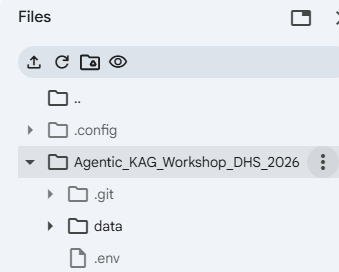

## Step 1 - Credentials & Drivers, Hygine aspects

### Why are we doing this?
To build our Knowledge Graph, we need two things:
1. A place to store the graph (the **Neo4j Database**).
2. A brain to understand the text (the **OpenAI API**).

This cell loads your secret keys and connection details from a `.env` file so the code can talk to these services securely.

**Logic Flow:**
`Load .env File` -> `Read Database URI/Password` -> `Set OpenAI API Key` -> `Print Confirmation`

In [5]:
import os

os.chdir('/content/Agentic_KAG_Workshop_DHS_2026/')

try:
    from dotenv import load_dotenv
    load_dotenv()
except Exception:
    print("error reading env details")
    pass

# --- Neo4j Sandbox ---
NEO4J_URI      = os.getenv('NEO4J_URI')
NEO4J_USERNAME = os.getenv('NEO4J_USERNAME')
NEO4J_PASSWORD = os.getenv('NEO4J_PASSWORD')
NEO4J_DATABASE = os.getenv('NEO4J_DATABASE')

# --- OpenAI ---
os.environ.setdefault(
    'OPENAI_API_KEY',
    os.getenv('OPENAI_API_KEY')
)

print('NEO4J_URI :', NEO4J_URI)
print('OPENAI key set:', bool(os.environ.get('OPENAI_API_KEY')))

NEO4J_URI : bolt://44.212.66.123
OPENAI key set: True


In [7]:
openai_key = os.environ.get('OPENAI_API_KEY')
if openai_key:
    print(f"OpenAI API Key successfully loaded")
else:
    print("OpenAI API Key not found. Please ensure it's set in your .env file or environment variables.")

OpenAI API Key successfully loaded


## Initialize LLM

In [8]:
from neo4j_graphrag.llm import OpenAILLM

# Initialize LLM
llm = OpenAILLM(
    model_name='gpt-5-mini',
)
print('LLM ready ✔')

LLM ready ✔


## 🧩 What is a Community?

In a knowledge graph, a **community** is a group of nodes that are **densely connected to each other**, but only **loosely connected to the rest of the graph**.

Think of it like real life:
- 👨‍👩‍👧 A **family** — everyone is closely linked to one another.
- 🎬 A **movie franchise** — the same actors, director, and genre keep appearing together.
- 🏙️ A **neighborhood** — houses close together form a cluster, far from other towns.

In our **Movie Knowledge Graph**, a community might naturally emerge as, for example:
> *"A cluster of sci-fi movies directed by Christopher Nolan, starring a recurring group of actors, produced by the same studio."*

The graph doesn't know this theme in advance — **community detection algorithms discover these clusters automatically** by looking at how nodes are connected.

### 🔍 What is Community *Detection*?

**Community detection** is the process of algorithmically finding these clusters. In this workshop we use the **Leiden algorithm** (an improved, more stable version of the popular Louvain algorithm). It:
1. Looks at the relationships between nodes.
2. Groups tightly-connected nodes together.
3. Assigns every node a `community` id — nodes with the same id belong to the same cluster.

## 🤔 Why Do We Need Communities?

A large knowledge graph can have **thousands or millions of nodes** — far too many for a human (or an LLM) to reason about directly. Communities help us by:

| Benefit | What it means |
|---------|----------------|
| **📉 Reducing complexity** | Instead of 10,000 nodes, we work with a handful of meaningful clusters. |
| **🧠 Revealing hidden themes** | Clusters expose patterns (genres, franchises, creative circles) we didn't explicitly define. |
| **📝 Enabling summarization** | We can ask an LLM to summarize *one community at a time* into plain English. |
| **⚡ Powering GraphRAG** | These community summaries become high-level "chapters" an LLM can retrieve and reason over — giving broad, thematic answers instead of scattered facts. |

> 💡 **Key idea for this workshop:** *Detect* clusters → *Summarize* each cluster with an LLM → *Reuse* those summaries to answer questions. That is the heart of **community-based GraphRAG**.


## ⚖️ Louvain vs. Leiden — Which Algorithm and Why?

Both **Louvain** and **Leiden** are popular community detection algorithms that optimize **modularity** (a score measuring how well nodes are grouped into clusters). In this workshop we use **Leiden**, which is a refined successor to Louvain.

| Aspect | Louvain (2008) | Leiden (2019) ✅ *used here* |
|--------|----------------|------------------------------|
| **Core idea** | Greedily merges nodes to maximize modularity | Same goal, but adds a *refinement* step |
| **Cluster quality** | Can produce **badly connected** or even **disconnected** communities | Guarantees communities are **well-connected** |
| **Stability** | Results can vary more between runs | More **stable and reproducible** |
| **Speed** | Fast | Fast — often **faster** at scale |
| **Availability in GDS** | `gds.louvain.*` | `gds.leiden.*` |

### 🎯 Why Leiden for our Movie Graph?
- It avoids the "broken cluster" problem, so our movie/actor/genre groups stay **meaningful and connected**.
- It's a near drop-in replacement — swapping to Louvain later is as easy as changing `gds.leiden.write` to `gds.louvain.write`.

> 💡 **Rule of thumb:** *Start with Leiden.* Only reach for Louvain if you are particular to use it :P

## 🎬 Step 2 — Define MovieCommunitySummarizer

The `MovieCommunitySummarizer` class automates the process of finding and describing thematic groups (communities) within a movie knowledge graph. Its core functionalities include:

1.   **Graph Projection and Community Detection**: It uses Neo4j's **Graph Data Science (GDS)** library to project the graph into memory and run the **Leiden algorithm** for community detection.
2.    **Community Retrieval and Summarization**: Once communities are identified, it retrieves their nodes and relationships, then leverages a **Large Language Model (LLM)** to generate human-readable summaries for each community.
3.   **Persistence and Cleanup**: These summaries are then **saved back into Neo4j** as `Community` nodes, and the in-memory GDS projection is dropped to clean up resources.

This pipeline is crucial for enabling **GraphRAG** applications by transforming complex graph data into digestible insights for LLMs, allowing them to reason over high-level themes rather than individual data points.

In [9]:
from neo4j import GraphDatabase

class MovieCommunitySummarizer:
    def __init__(self, driver,llm=None,graph_name='movie_graph'):
        self.driver=driver
        self.llm=llm
        self.graph_name=graph_name

    def project_graph(self):
        # Discover which labels and relationship types ACTUALLY exist in the DB.
        # GDS fails the whole projection if we list a relationship type that isn't
        # present, so we build the projection dynamically from the live schema.
        with self.driver.session() as s:
            labels = [r["label"] for r in s.run("CALL db.labels() YIELD label RETURN label")]
            rel_types = [
                r["relationshipType"]
                for r in s.run(
                    "CALL db.relationshipTypes() YIELD relationshipType RETURN relationshipType"
                )
            ]

        # Exclude the :Community label we write later so it doesn't pollute the projection
        labels = [l for l in labels if l != "Community"]

        if not labels or not rel_types:
            raise ValueError(
                "No labels/relationships found to project. "
                "Did you run the sample-data loader (Step 1)?"
            )

        rel_projection = {rt: {"orientation": "UNDIRECTED"} for rt in rel_types}

        with self.driver.session() as s:
            try:
                # yield an explicit column so we don't trigger the deprecated `schema` return
                s.run(
                    "CALL gds.graph.drop($g, false) YIELD graphName RETURN graphName",
                    g=self.graph_name,
                ).consume()
            except Exception:
                pass
            # .consume() forces the projection to actually run before we continue
            s.run(
                "CALL gds.graph.project($graph, $labels, $rels)",
                graph=self.graph_name,
                labels=labels,
                rels=rel_projection,
            ).consume()

        print(f"   Projected labels: {labels}")
        print(f"   Projected relationships: {rel_types}")

    def run_leiden(self):
        # IMPORTANT: consume the result so the write-back actually executes & commits.
        # Without .consume()/.data(), the auto-commit transaction may be discarded
        # before Leiden writes the `community` property -> 0 communities downstream.
        query = """
        CALL gds.leiden.write($g, {writeProperty: 'community'})
        YIELD communityCount, nodePropertiesWritten, modularity
        RETURN communityCount, nodePropertiesWritten, modularity
        """
        with self.driver.session() as s:
            record = s.run(query, g=self.graph_name).single()
        print(
            f"   Leiden wrote 'community' to {record['nodePropertiesWritten']} nodes "
            f"across {record['communityCount']} communities "
            f"(modularity={record['modularity']:.4f})"
        )
        return record

    def get_communities(self, member_limit=60):
        # Return COMPACT community data so we don't blow the LLM token limit.
        # - Only node name/title + primary label (not full properties)
        # - Relationship info as type counts (not every relationship w/ full targets)
        # `member_limit` caps how many member names we keep per community.
        q = '''
MATCH (n)
WHERE n.community IS NOT NULL
WITH n.community AS community,
     collect(DISTINCT coalesce(n.title, n.name, head(labels(n))))[0..$limit] AS members,
     count(DISTINCT n) AS size
RETURN community, members, size
ORDER BY size DESC
'''
        rels_q = '''
MATCH (n)-[r]-(m)
WHERE n.community = $cid AND m.community = $cid
RETURN type(r) AS rel_type, count(DISTINCT r) AS cnt
ORDER BY cnt DESC
'''
        with self.driver.session() as s:
            rows = [x.data() for x in s.run(q, limit=member_limit)]
            for row in rows:
                row['rel_counts'] = {
                    r['rel_type']: r['cnt']
                    for r in s.run(rels_q, cid=row['community'])
                }
        return rows

    async def summarize_community(self, c):
        # Build a compact prompt from the trimmed community data.
        members = c["members"]
        shown = ", ".join(str(m) for m in members)
        more = c["size"] - len(members)
        if more > 0:
            shown += f", ... (+{more} more)"
        rels = ", ".join(f"{k}:{v}" for k, v in c.get("rel_counts", {}).items()) or "none"
        prompt = (
            "You are summarizing a community from a Movie Knowledge Graph.\n"
            f"This community has {c['size']} members.\n"
            f"Relationship types (with counts): {rels}\n"
            f"Sample members: {shown}\n\n"
            "In 2-3 sentences, describe the common theme of this community "
            "(e.g. genre, language/industry, franchise, key people)."
        )
        if self.llm is None:
            return prompt
        result = await self.llm.ainvoke(prompt)
        return result.content if hasattr(result, 'content') else str(result)

    async def summarize_all(self):
        out = []
        for c in self.get_communities():
            out.append((c['community'], await self.summarize_community(c)))
        return out

    def save_summaries(self, summaries):
        # 1) Upsert the Community node with a STABLE, namespaced id plus useful
        #    properties (title, size) — not just the summary.
        #    - id: namespaced (e.g. "movie-community-3") so ids never collide
        #          with other pipelines and MERGE stays idempotent.
        #    - community_no: the raw Leiden integer, used to link members.
        #    - title: a short label derived from the first line/sentence of the summary.
        #    - size: number of member entities in the community.
        # 2) LINK every entity with this community id to the Community node, so the
        #    graph shows edges (entity)-[:IN_COMMUNITY]->(Community).
        upsert_q = '''
MERGE (c:Community {id:$node_id})
SET c.community_no = $cid,
    c.summary = $summary,
    c.title = $title
'''
        link_q = '''
MATCH (c:Community {id:$node_id})
MATCH (n)
WHERE n.community = $cid AND NOT n:Community
WITH c, collect(n) AS members
SET c.size = size(members)
FOREACH (n IN members | MERGE (n)-[:IN_COMMUNITY]->(c))
'''
        with self.driver.session() as s:
            for cid, summary in summaries:
                node_id = f"movie-community-{cid}"
                # Derive a short title from the first sentence/line of the summary.
                title = summary.strip().split("\n")[0].split(". ")[0][:80]
                s.run(upsert_q, node_id=node_id, cid=cid,
                      summary=summary, title=title).consume()
                s.run(link_q, node_id=node_id, cid=cid).consume()
        print(f"   Linked members to {len(summaries)} Community nodes via :IN_COMMUNITY")

    def drop_projection(self):
        with self.driver.session() as s:
            s.run(
                "CALL gds.graph.drop($g, false) YIELD graphName RETURN graphName",
                g=self.graph_name,
            ).consume()


## 🎬 Step 3 — Connect & Load existing Movie Graph

Before we can detect communities, we need a graph to work with. The cell below connects to your existing Neo4j instance using the config above.



In [10]:
from neo4j import GraphDatabase

# Connect to Neo4j
driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))

# Verify connectivity
driver.verify_connectivity()
print("✅ Connected to Neo4j at", NEO4J_URI)


✅ Connected to Neo4j at bolt://44.212.66.123


## 🚀 Step 4 — Run the Pipeline End-to-End

Now we put it all together. We'll run each stage and **print the output** so you can *see* what happens at every step:

1. **Project** the graph into GDS.
2. **Run Leiden** to assign community ids.
3. **Retrieve & inspect** the detected communities.
4. **Summarize** each community (LLM optional — runs in prompt-preview mode without one).
5. **Save** summaries back to Neo4j.
6. **Clean up** the in-memory projection.


**Note** - This step might take upto 5 min.

In [11]:
GRAPH_NAME = "MOVIE_GRAPH"

# Optional: quiet the harmless Neo4j notification warnings (property-not-yet-exists,
# deprecated `schema` return from gds.graph.drop). They don't affect the results.
import logging
logging.getLogger("neo4j.notifications").setLevel(logging.ERROR)

summarizer = MovieCommunitySummarizer(driver, llm, graph_name=GRAPH_NAME)

# 1) Project the graph into GDS
summarizer.project_graph()
print("✅ Step 1: Graph projected into GDS as", GRAPH_NAME)

# 2) Run Leiden community detection
summarizer.run_leiden()
print("✅ Step 2: Leiden finished — every node now has a 'community' property\n")

# 3) Retrieve & inspect the communities
communities = summarizer.get_communities()
print(f"🔎 Step 3: Detected {len(communities)} communities (showing largest first)\n")
for c in communities[:10]:
    preview = ", ".join(str(m) for m in c['members'][:8])
    print(f"  Community {c['community']} ({c['size']} members): {preview} ...")
print()

# 4) Summarize each community (LLM optional)
summaries = await summarizer.summarize_all()
print("📝 Step 4: Community summaries\n")
for cid, summary in summaries:
    print(f"--- Community {cid} ---")
    print(summary[:500], "\n")

# 5) Save summaries back to Neo4j as :Community nodes
summarizer.save_summaries(summaries)
print("✅ Step 5: Summaries saved as (:Community) nodes")

# 6) Clean up the in-memory projection
summarizer.drop_projection()
print("✅ Step 6: GDS projection dropped — pipeline complete! 🎉")

   Projected labels: ['__KGBuilder__', 'Movie', '__Entity__', 'Person', 'Genre', 'ProductionCompany', 'Country', 'Language', 'Keyword', 'Episodic', 'Entity']
   Projected relationships: ['DIRECTED_BY', 'CAST_IN', 'HAS_GENRE', 'PRODUCED_BY', 'PRODUCED_IN', 'SPOKEN_IN', 'TAGGED_WITH', 'RELATES_TO', 'HAS_MEMBER', 'MENTIONS']
✅ Step 1: Graph projected into GDS as MOVIE_GRAPH
   Leiden wrote 'community' to 5079 nodes across 36 communities (modularity=0.5721)
✅ Step 2: Leiden finished — every node now has a 'community' property

🔎 Step 3: Detected 36 communities (showing largest first)

  Community 6 (697 members): Action, based on novel or book, Thriller, Crime, drugs, Marathi, Lyca Productions, historical fiction ...
  Community 3 (606 members): Arabic, rescue mission, India, terrorist attack, parent child relationship, wrestling, training, womanhood ...
  Community 1 (574 members): Hindi, Nawazuddin Siddiqui, Pankaj Tripathi, Comedy, Aparshakti Khurana, caste system, Rajkummar Rao, Mahesh

# Now, Visualize the Communities on Neo4j Workspace

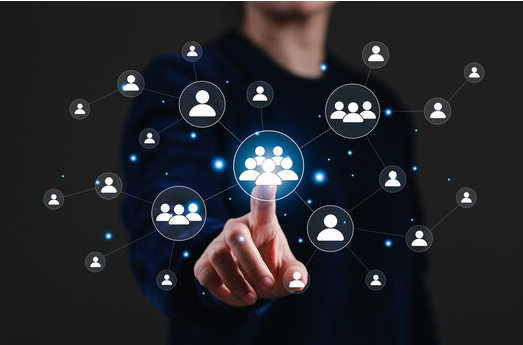

## 🧬 Step 5 — Store Summary Embeddings for Semantic Search

We embed each community
`summary` into a vector and store it on the `Community` node. A Neo4j **vector index** then
makes "find the communities most similar to this question" a single, fast query.

> 💡 Requires an embedding model.


In [12]:
# --- Configure an embedding model (optional) --------------------------------
%pip install --quiet langchain-openai
from langchain_openai import OpenAIEmbeddings
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")  # 1536 dims

EMBED_DIM = 1536  # match your model's output dimension
# ----------------------------------------------------------------------------

def embed_communities(driver, embeddings, dim=1536):
    if embeddings is None:
        print("⏭️  No embedding model configured — skipping (set `embeddings` above).")
        return

    # 1) Create a vector index on Community.embedding (id + cosine similarity).
    with driver.session() as s:
        s.run(
            """
            CREATE VECTOR INDEX community_embedding IF NOT EXISTS
            FOR (c:Community) ON (c.embedding)
            OPTIONS {indexConfig: {
                `vector.dimensions`: $dim,
                `vector.similarity_function`: 'cosine'
            }}
            """,
            dim=dim,
        ).consume()

        # 2) Fetch summaries, embed them, and write the vectors back.
        rows = [r.data() for r in s.run(
            "MATCH (c:Community) WHERE c.summary IS NOT NULL RETURN c.id AS id, c.summary AS summary"
        )]

    texts = [r["summary"] for r in rows]
    vectors = embeddings.embed_documents(texts)

    with driver.session() as s:
        for r, vec in zip(rows, vectors):
            s.run(
                "MATCH (c:Community {id:$id}) CALL db.create.setNodeVectorProperty(c, 'embedding', $vec)",
                id=r["id"], vec=vec,
            ).consume()
    print(f"✅ Embedded and indexed {len(rows)} community summaries "
          f"(index: 'community_embedding', {dim}-dim, cosine).")


embed_communities(driver, embeddings, EMBED_DIM)


✅ Embedded and indexed 36 community summaries (index: 'community_embedding', 1536-dim, cosine).


## 💡 How Do Communities Help Answer User Questions?

So far we detected communities and summarized them. But *why* does this make a question-answering
system better? Here's the intuition for beginners.

### 📚 The "book" analogy
Imagine a knowledge graph is a giant **library** with thousands of books (nodes):

- **Without communities** → answering a question means flipping through *every single book*. Slow,
  overwhelming, and easy to miss the point. (This is plain RAG dumping many raw facts at the LLM.)
- **With communities** → we've grouped the books into **themed shelves** (e.g. "Tamil action thrillers",
  "Pixar animations") and written a **one-paragraph blurb** for each shelf. Now answering is fast:
  read the blurbs, pick the right shelf, then look at just those books.

### 🔀 Two ways communities answer questions

| Question style | Example | What the graph does |
|----------------|---------|---------------------|
| 🌍 **Broad / thematic** | *"What kinds of movies are in this dataset?"* | Read **all community summaries** and synthesize — no need to look at individual movies. |
| 🔬 **Specific / entity** | *"Suggest gritty crime movies"* | Find the **most relevant community**, then follow `:IN_COMMUNITY` edges to its actual **movies**. |

### 🧠 Why this is powerful
- **Scales to huge graphs** — the LLM reasons over ~dozens of summaries instead of millions of nodes.
- **Cheaper & faster** — far fewer tokens sent to the LLM per question.
- **Better answers** — summaries give the LLM *context and themes*, so answers are coherent, not just
  a pile of disconnected facts.
- **Grounded** — because every summary links back to real nodes, we can always show the exact movies
  behind an answer (no hallucination).

> 🎯 **In one line:** communities turn a massive, messy graph into a small set of *meaningful,
> searchable chapters* — and that's what lets an LLM answer questions accurately and efficiently.


## 🔎 Step 6 — Community → Movie Retrieval for GraphRAG

This is where communities pay off. Given a user question we:

1. **Find the most relevant communities** — by semantic similarity if embeddings exist,
   otherwise by a simple keyword match on the summary/title.
2. **Traverse `:IN_COMMUNITY`** from those communities down to their **`Movie`** members.
3. **Hand the LLM** the community summaries + the movies as grounded context to answer.

This is the essence of **community-based GraphRAG**: retrieve a *theme*, then drill into its entities.


In [14]:
def find_relevant_communities(driver, question, embeddings=None, top_k=3):
    """Return the top-k communities most relevant to `question`.

    Uses the vector index when an embedding model is available, otherwise
    falls back to a simple keyword CONTAINS match on the summary/title.
    """
    if embeddings is not None:
        qvec = embeddings.embed_query(question)
        cypher = """
        CALL db.index.vector.queryNodes('community_embedding', $k, $qvec)
        YIELD node, score
        RETURN node.id AS id, node.title AS title, node.summary AS summary, score
        ORDER BY score DESC
        """
        params = {"k": top_k, "qvec": qvec}
    else:
        # Keyword fallback: match any word from the question against summary/title.
        words = [w for w in question.lower().split() if len(w) > 3]
        cypher = """
        MATCH (c:Community)
        WHERE any(w IN $words WHERE toLower(coalesce(c.summary,'') + ' ' + coalesce(c.title,'')) CONTAINS w)
        RETURN c.id AS id, c.title AS title, c.summary AS summary, 0.0 AS score
        LIMIT $k
        """
        params = {"words": words, "k": top_k}

    with driver.session() as s:
        return [r.data() for r in s.run(cypher, **params)]


def movies_in_communities(driver, community_ids, limit_per_community=10):
    """Traverse :IN_COMMUNITY to fetch Movie members for the given communities."""
    cypher = """
    MATCH (c:Community)<-[:IN_COMMUNITY]-(m:Movie)
    WHERE c.id IN $ids
    WITH c, collect(DISTINCT m.title)[0..$lim] AS movies
    RETURN c.id AS community, c.title AS title, movies
    """
    with driver.session() as s:
        return [r.data() for r in s.run(cypher, ids=community_ids, lim=limit_per_community)]


def graphrag_answer(driver, question, llm=None, embeddings=None, top_k=3):
    # 1) Retrieve the most relevant community "chapters".
    comms = find_relevant_communities(driver, question, embeddings, top_k)
    if not comms:
        return "No relevant communities found. Have you run Steps 2–4?"

    # 2) Drill into the movies that belong to those communities.
    ids = [c["id"] for c in comms]
    movie_rows = movies_in_communities(driver, ids)

    # 3) Build grounded context.
    context_lines = []
    for c in comms:
        movies = next((m["movies"] for m in movie_rows if m["community"] == c["id"]), [])
        context_lines.append(
            f"- Community '{c.get('title') or c['id']}': {c['summary']}\n"
            f"  Movies: {', '.join(movies) if movies else '(none)'}"
        )
    context = "\n".join(context_lines)

    prompt = (
        "Answer the question using ONLY the community context below.\n\n"
        f"Question: {question}\n\n"
        f"Community context:\n{context}\n\n"
        "Give a concise, grounded answer and mention relevant movies."
    )

    if llm is None:
        # No LLM: return the retrieved context so you can see what GraphRAG would use.
        return "🔎 Retrieved context (no LLM configured):\n\n" + context
    result = llm.invoke(prompt) if hasattr(llm, "invoke") else None
    return getattr(result, "content", str(result))



❓ Recommend some historical big hits

Here are some standout historical/period big hits from the communities you provided:

- RRR — Telugu period epic (1920s, large‑scale freedom‑fighter spectacle).  
- Bāhubali 2: The Conclusion — Tollywood kingdom epic, grand action and scale.  
- The Ghazi Attack — war/submarine period drama (wartime naval conflict).  
- Padmaavat — Bollywood historical/period epic (grand visuals and royal setting).  
- Gangubai Kathiawadi — Bollywood period biopic/drama with strong historical setting.

These match the community themes of kingdoms, colonial/period settings, war/revolution and large‑scale spectacle.


In [15]:

# --- Try it! -----------------------------------------------------------------
question = "Recommend some historical big hits in Tamil"
print(f"❓ {question}\n")
print(graphrag_answer(driver, question, llm=llm, embeddings=embeddings, top_k=3))


❓ Recommend some historical big hits in Tamil

If you mean big‑budget historical/period epics that Tamil audiences often watch, check these from the community clusters:

- Bāhubali 2: The Conclusion — epic kingdom/period spectacle, massive pan‑Indian hit.  
- RRR — large‑scale freedom‑fighter/colonial‑era action drama.  
- The Ghazi Attack — wartime/submarine period war film.  
- K.G.F: Chapter 1 and K.G.F: Chapter 2 — gritty period/gold‑mine action epics (Kannada originals, widely seen across languages).  
- Kantara — folk/period‑toned epic rooted in local folklore.

(If you want strictly Tamil‑language titles from the context, Vikram and Vishwaroopam II are major Tamil action hits but are contemporary thrillers rather than historical period pieces.)


## 🤖 Step 7 — Expose Global & Local Search as Tools

GraphRAG traditionally offers **two complementary search modes**. We wrap each as a LangChain
`@tool` so a **ReAct agent** can decide which to call:

| Tool | Scope | Answers questions like | How it works |
|------|-------|------------------------|--------------|
| 🌍 **`global_search`** | Whole graph, *theme-level* | *"What kinds of movies are in this dataset?"* | Reads **all community summaries** and reasons over them |
| 🔬 **`local_search`** | A specific entity/topic | *"Which crime movies feature Leonardo DiCaprio?"* | Finds the most relevant communities, then drills into their **Movie** members |

The agent reads the tool **descriptions** to route each question to the right tool — global for
broad/aggregate questions, local for specific/entity questions.

> 💡 Needs a chat `llm`. Uses the community data already stored in Neo4j from the previous steps.


In [16]:
# %pip install --quiet langchain langchainhub langchain-openai
from langchain_core.tools import tool


# --- Helpers backing the tools ----------------------------------------------
def _all_community_summaries(driver, limit=100):
    q = """
    MATCH (c:Community)
    WHERE c.summary IS NOT NULL
    RETURN c.id AS id, c.title AS title, c.summary AS summary, coalesce(c.size, 0) AS size
    ORDER BY size DESC
    LIMIT $limit
    """
    with driver.session() as s:
        return [r.data() for r in s.run(q, limit=limit)]


# --- TOOL 1: GLOBAL SEARCH (theme-level, whole graph) ------------------------
@tool
def global_search(question: str) -> str:
    """Answer BROAD, thematic, or aggregate questions about the ENTIRE movie dataset
    (e.g. "what genres/themes exist?", "summarize the dataset", "what kinds of movies
    are here?"). It reasons over ALL community summaries, not individual movies.
    Use this when the question is high-level and not about one specific movie/person."""
    comms = _all_community_summaries(driver)
    if not comms:
        return "No community summaries found. Run Steps 2–4 first."
    context = "\n".join(
        f"- {c.get('title') or c['id']} ({c['size']} members): {c['summary']}"
        for c in comms
    )
    if llm is None:
        return "🔎 (no LLM) Community summaries:\n\n" + context
    prompt = (
        "You are answering a BROAD question about a movie dataset using the "
        "community summaries below. Synthesize across communities.\n\n"
        f"Question: {question}\n\nCommunity summaries:\n{context}\n\n"
        "Give a concise, thematic answer."
    )
    return getattr(llm.invoke(prompt), "content", "")


# --- TOOL 2: LOCAL SEARCH (entity/topic-specific) ---------------------------
@tool
def local_search(question: str) -> str:
    """Answer SPECIFIC questions about particular movies, people, genres, or narrow topics
    (e.g. "which crime movies feature actor X?", "movies about time travel"). It finds the most relevant communities, then drills into their Movie members for grounded detail.
    Use this when the question targets specific entities rather than the whole dataset."""
    comms = find_relevant_communities(driver, question, embeddings=embeddings, top_k=3)
    if not comms:
        return "No relevant communities found. Run Steps 2–4 first."
    ids = [c["id"] for c in comms]
    movie_rows = movies_in_communities(driver, ids)
    context_lines = []
    for c in comms:
        movies = next((m["movies"] for m in movie_rows if m["community"] == c["id"]), [])
        context_lines.append(
            f"- {c.get('title') or c['id']}: {c['summary']}\n"
            f"  Movies: {', '.join(movies) if movies else '(none)'}"
        )
    context = "\n".join(context_lines)
    if llm is None:
        return "🔎 (no LLM) Retrieved context:\n\n" + context
    prompt = (
        "Answer the question using ONLY the community context below.\n\n"
        f"Question: {question}\n\nCommunity context:\n{context}\n\n"
        "Give a concise, grounded answer and mention relevant movies."
    )
    return getattr(llm.invoke(prompt), "content", "")


tools = [global_search, local_search]
print("✅ Tools ready:", [t.name for t in tools])

✅ Tools ready: ['global_search', 'local_search']


#### Invoke the `global search` & `local search` tool with specific questions

> The **global_search** tool is designed to answer broad, thematic questions

> The **local_search** tool is designed to answer about a particular topic, theme, person, or a shortlist of movies





In [21]:
from IPython.display import Markdown

# 🌍 Broad / thematic question
print("=== global_search ===")
Markdown(global_search.invoke("WHAT ARE THE THEMES OF THRILLERS"))

=== global_search ===


Common themes that run across the thriller clusters:

- Crime and investigation: police procedurals, detective-led whodunits, serial‑killer hunts and forensic sleuthing — the core engine for suspense and truth‑seeking.  
- Psychological tension and unreliable perception: mind games, memory gaps, obsessions and identity crises that blur reality and motive.  
- Legal and moral justice: courtroom battles, investigations into institutional failure, wrongful accusations and contested truth.  
- Espionage and political/war stakes: spycraft, national security, India–Pakistan tension, hijackings and terrorism narratives.  
- Revenge, vigilantism and moral ambiguity: personal vendettas, extra‑legal justice and the ethical cost of retribution.  
- Social‑issue intersection: thrillers used to examine caste, patriarchy, sexual assault, corruption and other systemic injustices.  
- Action and spectacle: high‑octane chases, stunts and military/spy action that prioritize pace and set‑piece tension.  
- Supernatural and genre hybrids: blends with horror, mythic elements or folklore to create uncanny suspense.  
- Sci‑fi/time‑displacement suspense: time travel, future shock and technological puzzles that reframe stakes and choices.  
- Family and relational stakes: domestic secrets, betrayal, custody and intimate relationships driving the mystery.  
- Structural/suspense devices: non‑linear timelines, flashbacks, macguffins, red herrings and ensemble reveals to sustain mystery.  
- Regional and industry flavors: variations in tone and focus across industries — gritty, realistic investigations in Tamil/Malayalam; socially conscious/legal thrillers in Hindi; large‑scale epic/period action in Telugu/Kannada; indie/festival psychological and arthouse approaches internationally.

These themes often overlap—thrillers commonly combine investigation, psychological tension and social or political stakes to keep moral questions and suspense tightly intertwined.

In [22]:
from IPython.display import Markdown

# 🌍 Broad / thematic question
print("=== global_search ===")
Markdown(global_search.invoke("WHAT ARE THE THEMES OF HORRORS AND COMEDY"))

=== global_search ===


Horror — common themes
- Supernatural & folklore: curses, spirits, demonic possession, village myths and mythic artifacts (folk/folk‑horror motifs).  
- Mythic/astral scales: myth, spiritual journeys, dreamlike or otherworldly realms, destiny and sacrifice.  
- Psychological dread & mystery: paranoia, guilt, identity, unreliable perception, investigative/whodunit overlaps.  
- Social anxieties rendered as horror: tradition vs modernity, greed, family secrets, patriarchy and community guilt.  
- Atmosphere and suspense: slow‑burn tension, hauntings, uncanny spaces (mansions, rural settings) and moral ambiguity.  
- Genre crossovers: horror blended with thriller, crime, or arthouse/festival‑style experimental horror.

Comedy — common themes
- Social satire & conscience: comedies used to critique caste, education, patriarchy, social norms and institutions.  
- Family and relationships: interpersonal humor from domestic life, marriage, parenting, generational clash.  
- Situational and ensemble humor: workplace, buddy/ensemble antics, mistaken identity and farce (mainstream Bollywood style).  
- Dramedy / tonal balance: light treatment of serious issues (health, stigma, bureaucracy) — socially conscious comedies.  
- Romantic and coming‑of‑age beats: love, youth misadventures, personal growth framed comically.  
- Regional flavor & star‑driven style: language/industry‑specific comic traditions (Hindi/Tamil/Malayalam slapstick, observational wit, star personas).

Overlap and hybrids
- Horror‑comedy and dark comedy frequently mix myth/folklore scares with satirical social critique, or use humor to undercut tension.  
- Both genres often explore social issues (patriarchy, greed, village power dynamics) but with different tones—horror through dread and metaphor, comedy through satire and relief.

In [25]:
# 🔬 Specific / entity question
print("\n=== local_search ===")
Markdown(local_search.invoke("List all the movies featuring Anushka"))


=== local_search ===


From the movies listed in the community context, Anushka (Anushka Shetty) appears in:
- Bāhubali 2: The Conclusion